# Firefly Algorithm (อัลกอริทึมหิ่งห้อย)

| | |
|---|---|
| **ผู้คิดค้น** | Xin-She Yang — มหาวิทยาลัยเคมบริดจ์, 2008 (หนังสือ *Nature-Inspired Metaheuristic Algorithms*) |
| **ประเภท** | Metaheuristic / Swarm Intelligence — หาคำตอบที่ดีที่สุด (optimization) โดย **ไม่ต้องใช้อนุพันธ์** |
| **แรงบันดาลใจ** | หิ่งห้อยกะพริบแสงเพื่อดึงดูดกัน — ตัวที่แสงจางกว่าจะบินเข้าหาตัวที่สว่างกว่า |
| **ใช้ทำอะไร** | หาค่าต่ำสุด/สูงสุดของฟังก์ชันที่ซับซ้อน มีหลายหลุม (multimodal) เช่น ออกแบบวิศวกรรม, จูน hyperparameter, จัดตารางงาน |

## กฎ 3 ข้อของหิ่งห้อย

1. หิ่งห้อยทุกตัวดึงดูดกันได้หมด (ไม่แบ่งเพศ)
2. **ความดึงดูดขึ้นกับความสว่าง** — ตัวที่สว่างน้อยกว่าบินเข้าหาตัวที่สว่างกว่า และความสว่างที่ "มองเห็น" **ลดลงตามระยะทาง**
3. **ความสว่างมาจากค่าฟังก์ชันเป้าหมาย** — ถ้าหาค่าต่ำสุด: ค่า $f(\mathbf{x})$ ยิ่งน้อย = ยิ่งสว่าง

## 1. สูตรที่ใช้

**ระยะห่างระหว่างหิ่งห้อย $i$ กับ $j$:**
$$ r_{ij} = \lVert \mathbf{x}_i - \mathbf{x}_j \rVert = \sqrt{\sum_k (x_{i,k} - x_{j,k})^2} $$

**ความดึงดูด** (ลดลงแบบเอกซ์โพเนนเชียลตามระยะ — เหมือนแสงถูกอากาศดูดกลืน):
$$ \beta(r) = \beta_0 \, e^{-\gamma r^2} $$

**การเคลื่อนที่** ของหิ่งห้อย $i$ เข้าหาหิ่งห้อย $j$ ที่สว่างกว่า:
$$
\mathbf{x}_i \leftarrow \mathbf{x}_i
+ \underbrace{\beta_0 e^{-\gamma r_{ij}^2} (\mathbf{x}_j - \mathbf{x}_i)}_{\text{attractiveness } j}
+ \underbrace{\alpha \, \boldsymbol{\varepsilon}_i}_{\text{Stepsize}}
$$

| พารามิเตอร์ | ความหมาย | ค่าที่นิยม |
|---|---|---|
| $\beta_0$ | ความดึงดูดที่ระยะ 0 | 1 |
| $\gamma$ | ค่าการดูดกลืนแสง — ยิ่งมาก ยิ่งมองเห็นกันแค่ระยะใกล้ | 0.01 – 10 (ขึ้นกับขนาดโดเมน) |
| $\alpha$ | ขนาดของการสุ่ม | 0.1 – 0.5 (ค่อยๆ ลดลงทุกรอบ) |
| $\boldsymbol{\varepsilon}_i$ | เวกเตอร์สุ่ม แต่ละมิติจาก Uniform$(-0.5, 0.5)$ | — |

> 💡 **เคสสุดขั้วของ $\gamma$:** ถ้า $\gamma \to 0$ ทุกตัวเห็นตัวที่สว่างที่สุดชัดเจน (คล้าย PSO) · ถ้า $\gamma \to \infty$ มองไม่เห็นใครเลย = random search
> ค่ากลางๆ ทำให้ฝูง **แตกเป็นกลุ่มย่อย** ไปสำรวจหลายหลุมพร้อมกัน — จุดเด่นของ Firefly Algorithm

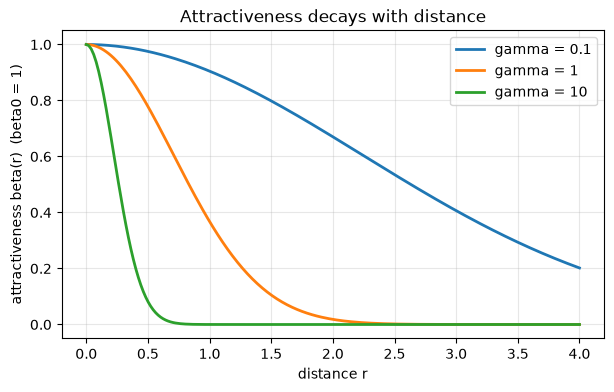

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

r = np.linspace(0, 4, 200)
plt.figure(figsize=(7, 4))
for g in [0.1, 1, 10]:
    plt.plot(r, np.exp(-g * r**2), lw=2, label=f"gamma = {g}")
plt.xlabel("distance r"); plt.ylabel("attractiveness beta(r)  (beta0 = 1)")
plt.title("Attractiveness decays with distance")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 2. ตัวอย่างการคำนวณด้วยมือ: ขยับหิ่งห้อย 1 ครั้ง

หาค่าต่ำสุดของ $f(x, y) = x^2 + y^2$ (คำตอบที่แท้จริงคือ $(0, 0)$, $f = 0$)

| หิ่งห้อย | ตำแหน่ง | $f$ | ความสว่าง |
|:-:|:-:|:-:|---|
| $i$ | $(2, 1)$ | $4 + 1 = 5$ | มืดกว่า |
| $j$ | $(0.5, 0.5)$ | $0.25 + 0.25 = 0.5$ | **สว่างกว่า** → $i$ ต้องบินเข้าหา $j$ |

ใช้ $\beta_0 = 1$, $\gamma = 1$, $\alpha = 0.2$ และสมมติว่าสุ่มได้ $\boldsymbol{\varepsilon} = (0.1, -0.3)$

**ขั้นที่ 1 — ระยะทางกำลังสอง**
$$ r^2 = (2 - 0.5)^2 + (1 - 0.5)^2 = 2.25 + 0.25 = 2.5 $$

**ขั้นที่ 2 — ความดึงดูด**
$$ \beta = 1 \cdot e^{-1 \times 2.5} = e^{-2.5} \approx 0.0821 $$

**ขั้นที่ 3 — แรงดึง**
$$ \beta(\mathbf{x}_j - \mathbf{x}_i) = 0.0821 \times (0.5 - 2,\; 0.5 - 1) = 0.0821 \times (-1.5, -0.5) = (-0.1231, -0.0410) $$

**ขั้นที่ 4 — ส่วนสุ่ม**
$$ \alpha \boldsymbol{\varepsilon} = 0.2 \times (0.1, -0.3) = (0.02, -0.06) $$

**ขั้นที่ 5 — ตำแหน่งใหม่**
$$ \mathbf{x}_i^{\text{new}} = (2 - 0.1231 + 0.02,\;\; 1 - 0.0410 - 0.06) = (1.8969,\; 0.8990) $$

**ผล:** $f$ ลดจาก $5$ เหลือ $1.8969^2 + 0.8990^2 \approx 4.406$ — หิ่งห้อย $i$ "สว่างขึ้น" แล้ว ✨

> สังเกตว่า $\beta$ เล็กมาก (0.08) เพราะอยู่ห่างกัน ถ้าลด $\gamma$ เป็น 0.1 จะได้ $\beta = e^{-0.25} \approx 0.78$ → กระโดดเข้าไปใกล้ $j$ มากกว่าเดิมเกือบ 10 เท่า

ตรวจด้วยโค้ด:

In [18]:
f = lambda p: np.sum(p**2)
xi, xj = np.array([2.0, 1.0]), np.array([0.5, 0.5])
beta0, gamma, alpha = 1.0, 1.0, 0.2
eps = np.array([0.1, -0.3])

r2 = np.sum((xi - xj) ** 2)
beta = beta0 * np.exp(-gamma * r2)
pull = beta * (xj - xi)
rand = alpha * eps
x_new = xi + pull + rand

print(f"r^2      = {r2:.4f}")
print(f"beta     = e^(-{gamma * r2:g}) = {beta:.4f}")
print(f"pull     = {np.round(pull, 4)}")
print(f"random   = {np.round(rand, 4)}")
print(f"x_new    = {np.round(x_new, 4)}")
print(f"f: {f(xi):.4f} -> {f(x_new):.4f}")

r^2      = 2.5000
beta     = e^(-2.5) = 0.0821
pull     = [-0.1231 -0.041 ]
random   = [ 0.02 -0.06]
x_new    = [1.8969 0.899 ]
f: 5.0000 -> 4.4062


## 3. อัลกอริทึมเต็ม

```
สุ่มตำแหน่งหิ่งห้อย n ตัวในโดเมน, คำนวณ f ของแต่ละตัว
วนรอบ t = 1 … T:
    สำหรับหิ่งห้อย i ทุกตัว:
        สำหรับหิ่งห้อย j ทุกตัว:
            ถ้า f(x_j) < f(x_i):            # j สว่างกว่า
                ขยับ x_i เข้าหา x_j ตามสูตร
                ตัดให้อยู่ในโดเมน แล้วคำนวณ f(x_i) ใหม่
    α ← α · δ                                 # ลดการสุ่มลงทีละนิด (δ ≈ 0.97)
    บันทึกตัวที่ดีที่สุด
```

ส่วนสุ่มคูณด้วย **ความกว้างของโดเมน** (upper − lower) เพื่อให้ $\alpha$ ใช้ได้กับทุกขนาดปัญหา

In [19]:
def firefly(f, lower, upper, n=25, iters=60, beta0=1.0, gamma=1.0, alpha=0.2, delta=0.97, seed=0):
    rng = np.random.default_rng(seed)
    lower, upper = np.asarray(lower, float), np.asarray(upper, float)
    scale = upper - lower
    X = rng.uniform(lower, upper, size=(n, len(lower)))
    F = np.array([f(x) for x in X])
    positions, best_f = [X.copy()], [F.min()]

    for t in range(iters):
        for i in range(n):
            for j in range(n):
                if F[j] < F[i]:
                    r2 = np.sum((X[i] - X[j]) ** 2)
                    beta = beta0 * np.exp(-gamma * r2)
                    eps = rng.uniform(-0.5, 0.5, size=len(lower))
                    X[i] = np.clip(X[i] + beta * (X[j] - X[i]) + alpha * eps * scale, lower, upper)
                    F[i] = f(X[i])
        alpha *= delta
        positions.append(X.copy())
        best_f.append(F.min())

    best = np.argmin(F)
    return X[best], F[best], positions, np.array(best_f)

## 4. ทดสอบกับฟังก์ชันยาก: Ackley Function

$$
f(x, y) = -20\, e^{-0.2\sqrt{0.5(x^2 + y^2)}} - e^{0.5(\cos 2\pi x + \cos 2\pi y)} + e + 20
$$

มี **หลุมเล็กๆ (local minima) นับร้อย** กระจายทั่วพื้นที่ แต่มีจุดต่ำสุดจริงแค่จุดเดียวที่ $(0, 0)$ ซึ่ง $f = 0$
วิธีอย่าง Gradient Descent มักติดหลุมเล็ก — มาดูว่าหิ่งห้อยหาเจอไหม

คำตอบที่ดีที่สุด: x = [-4.05e-03 -7.00e-05],  f = 0.011898   (คำตอบจริง: (0, 0), f = 0)


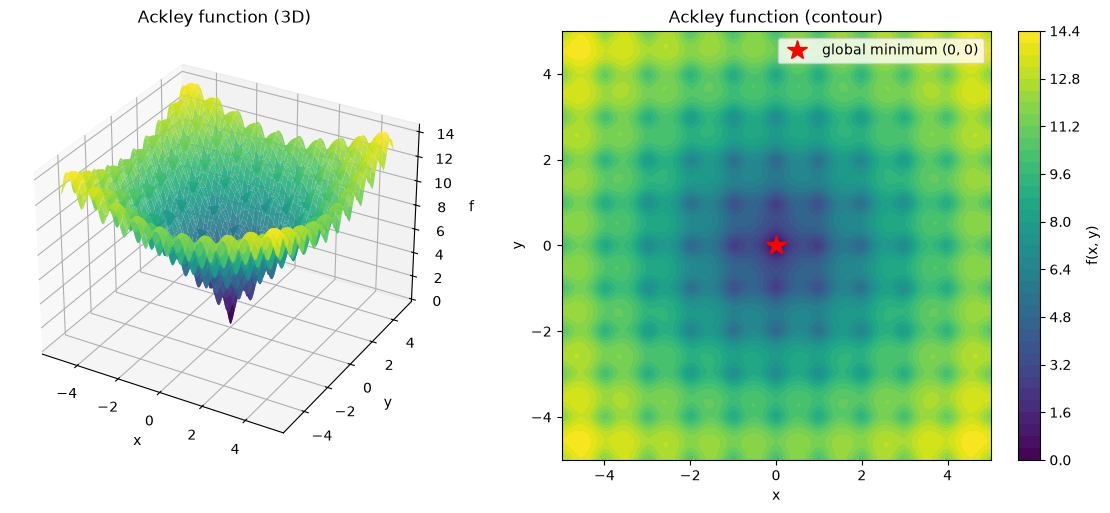

In [20]:
def ackley(p):
    x, y = p
    return (-20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
            - np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))) + np.e + 20)


LO, HI = [-5, -5], [5, 5]
best_x, best_val, positions, best_curve = firefly(ackley, LO, HI, n=25, iters=60, gamma=1.0, seed=1)
print(f"คำตอบที่ดีที่สุด: x = {np.round(best_x, 5)},  f = {best_val:.6f}   (คำตอบจริง: (0, 0), f = 0)")

gx = np.linspace(-5, 5, 300)
GX, GY = np.meshgrid(gx, gx)
GZ = ackley((GX, GY))

fig = plt.figure(figsize=(12, 5))
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax3d.plot_surface(GX, GY, GZ, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
ax3d.set(title="Ackley function (3D)", xlabel="x", ylabel="y", zlabel="f")
ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(GX, GY, GZ, levels=40, cmap="viridis")
fig.colorbar(cs, ax=ax2, label="f(x, y)")
ax2.plot(0, 0, "r*", ms=15, label="global minimum (0, 0)")
ax2.set(title="Ackley function (contour)", xlabel="x", ylabel="y"); ax2.set_aspect("equal"); ax2.legend()
plt.tight_layout()
plt.show()

## 5. ดูหิ่งห้อยบินเข้าหาคำตอบ

แต่ละภาพคือตำแหน่งของหิ่งห้อยทั้ง 25 ตัวในรอบต่างๆ — **สีของจุดคือความสว่าง** (เหลือง = ค่า $f$ ต่ำ = สว่าง)

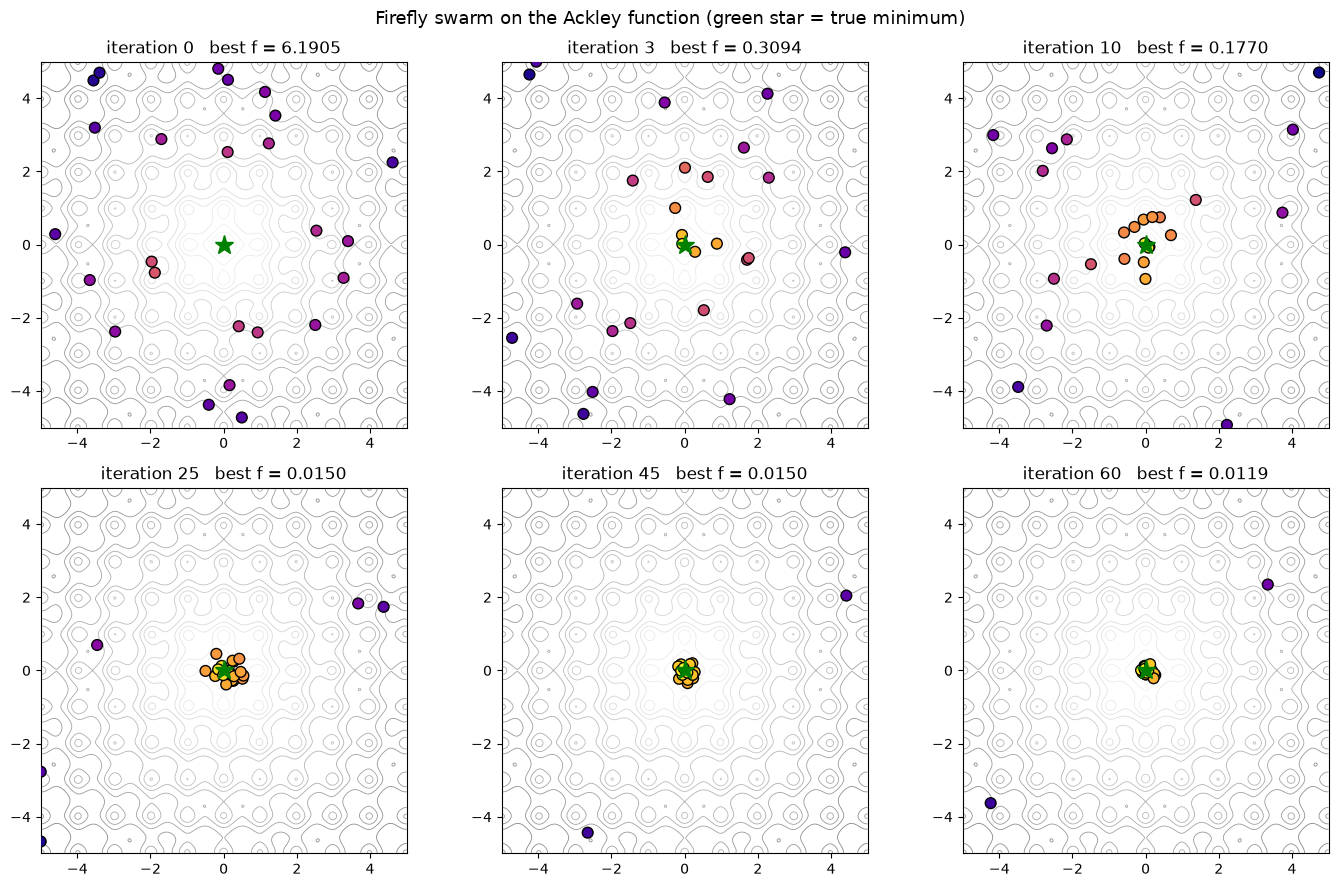

In [21]:
snapshots = [0, 3, 10, 25, 45, 60]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, t in zip(axes.ravel(), snapshots):
    P = positions[t]
    vals = np.array([ackley(p) for p in P])
    ax.contour(GX, GY, GZ, levels=20, cmap="Greys", alpha=0.5, linewidths=0.6)
    ax.scatter(P[:, 0], P[:, 1], c=vals, cmap="plasma_r", vmin=0, vmax=14, s=60, edgecolors="k", zorder=3)
    ax.plot(0, 0, "g*", ms=14, zorder=4)
    ax.set(xlim=(-5, 5), ylim=(-5, 5), title=f"iteration {t}   best f = {vals.min():.4f}")
    ax.set_aspect("equal")
plt.suptitle("Firefly swarm on the Ackley function (green star = true minimum)", fontsize=13)
plt.tight_layout()
plt.show()

### เส้นทางการบินของหิ่งห้อยแต่ละตัว

เส้นแต่ละสีคือเส้นทางของหิ่งห้อย 1 ตัวตลอดทุกรอบ (● = จุดเริ่ม, ■ = จุดสุดท้าย)

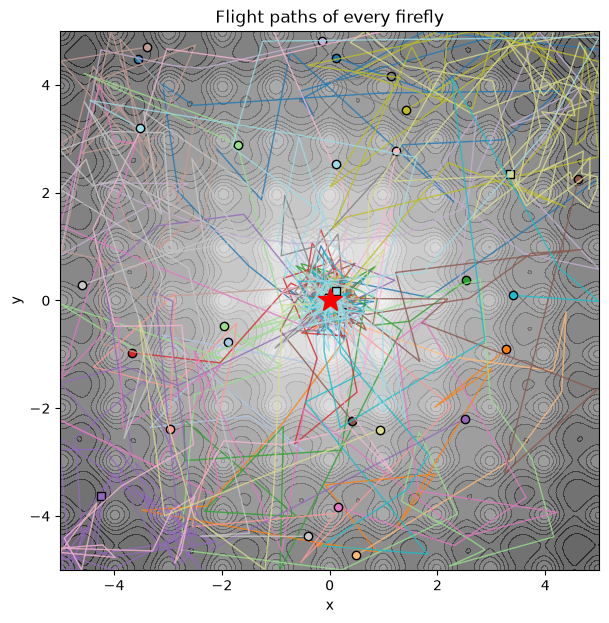

In [22]:
traj = np.stack(positions)
fig, ax = plt.subplots(figsize=(7, 7))
ax.contourf(GX, GY, GZ, levels=40, cmap="Greys", alpha=0.6)
colors = plt.cm.tab20(np.linspace(0, 1, traj.shape[1]))
for k in range(traj.shape[1]):
    ax.plot(traj[:, k, 0], traj[:, k, 1], "-", color=colors[k], lw=1, alpha=0.8)
    ax.plot(*traj[0, k], "o", color=colors[k], ms=6, mec="k")
    ax.plot(*traj[-1, k], "s", color=colors[k], ms=6, mec="k")
ax.plot(0, 0, "r*", ms=18, zorder=5)
ax.set(xlim=(-5, 5), ylim=(-5, 5), xlabel="x", ylabel="y", title="Flight paths of every firefly")
ax.set_aspect("equal")
plt.show()

## 6. กราฟการลู่เข้า (Convergence)

ค่า $f$ ของหิ่งห้อยที่ดีที่สุดในแต่ละรอบ — ใช้สเกล log เพื่อให้เห็นช่วงท้ายที่ค่าเล็กมาก

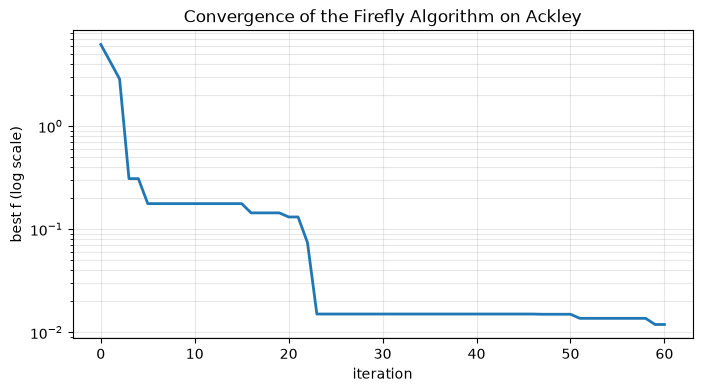

In [23]:
plt.figure(figsize=(8, 4))
plt.semilogy(best_curve + 1e-16, lw=2)
plt.xlabel("iteration"); plt.ylabel("best f (log scale)")
plt.title("Convergence of the Firefly Algorithm on Ackley")
plt.grid(alpha=0.3, which="both")
plt.show()

## 7. ผลของพารามิเตอร์ $\gamma$

ลองรันซ้ำด้วย $\gamma$ ต่างกัน (ใช้จุดเริ่มต้นสุ่มชุดเดียวกัน) แล้วเปรียบเทียบ:
- $\gamma$ **เล็กมาก** → ทุกตัวถูกดึงไปหาตัวที่สว่างที่สุดพร้อมกัน รวมตัวเร็ว แต่ถ้าเลือกหลุมผิดก็ผิดทั้งฝูง
- $\gamma$ **ใหญ่มาก** → มองเห็นกันแค่ระยะใกล้ เกือบเป็นการเดินสุ่ม

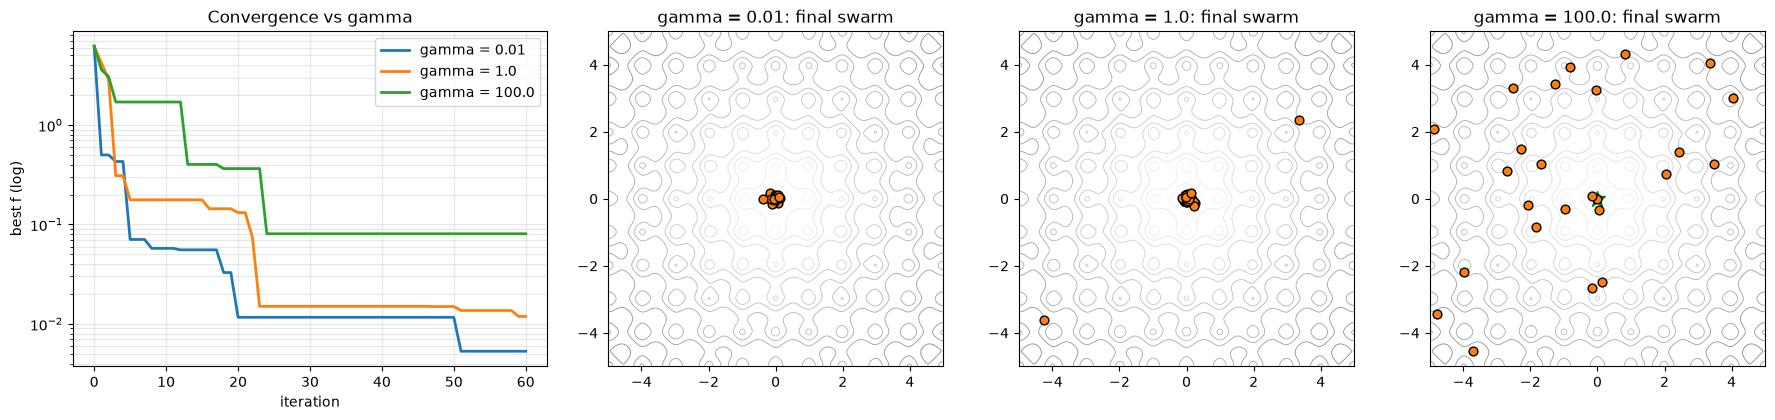

 gamma   best f             best x  final spread (std)
  0.01 0.005314 [-0.0018, -0.0006]             0.08983
     1   0.0119 [-0.0041, -0.0001]              0.9751
   100  0.08064  [-0.0234, 0.0011]               2.412


In [24]:
gammas = [0.01, 1.0, 100.0]
results = []
fig, axes = plt.subplots(1, 4, figsize=(18, 4.3), gridspec_kw={"width_ratios": [1.3, 1, 1, 1]})
for g in gammas:
    bx, bv, pos, curve = firefly(ackley, LO, HI, n=25, iters=60, gamma=g, seed=1)
    results.append({"gamma": g, "best f": bv, "best x": np.round(bx, 4),
                    "final spread (std)": pos[-1].std(axis=0).mean()})
    axes[0].semilogy(curve + 1e-16, lw=2, label=f"gamma = {g}")
    ax = axes[gammas.index(g) + 1]
    ax.contour(GX, GY, GZ, levels=15, cmap="Greys", alpha=0.5, linewidths=0.6)
    ax.scatter(pos[-1][:, 0], pos[-1][:, 1], c="tab:orange", s=40, edgecolors="k", zorder=3)
    ax.plot(0, 0, "g*", ms=12)
    ax.set(xlim=(-5, 5), ylim=(-5, 5), title=f"gamma = {g}: final swarm")
    ax.set_aspect("equal")
axes[0].set(xlabel="iteration", ylabel="best f (log)", title="Convergence vs gamma")
axes[0].legend(); axes[0].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print(pd.DataFrame(results).to_string(index=False, float_format=lambda v: f"{v:.4g}"))

**อ่านผล:** ดูคอลัมน์ `final spread` — ค่านี้บอกว่าฝูงกระจายตัวแค่ไหนในรอบสุดท้าย
- $\gamma = 0.01$: ทุกตัวรวมเป็นกลุ่มเดียวแน่นมาก — ในโจทย์นี้บังเอิญรวมตัวถูกหลุม จึงได้ผลดี แต่ถ้าตัวที่สว่างที่สุดช่วงแรกอยู่ผิดหลุม ทั้งฝูงจะตามไปผิดหมด
- $\gamma = 1$: ฝูงแตกเป็นกลุ่มย่อยหลายกลุ่ม (ดูภาพกลาง) — ช้ากว่าเล็กน้อยแต่ **ปลอดภัยกว่า** ในปัญหาที่มีหลายหลุม
- $\gamma = 100$: หิ่งห้อยแทบมองไม่เห็นกัน ฝูงกระจายทั่วพื้นที่ ผลแย่ที่สุด

ลองเปลี่ยน `seed` เป็นค่าอื่นหลายๆ ค่า แล้วดูว่า $\gamma$ ไหนได้ผลดี **สม่ำเสมอ** ที่สุด

## 8. แบบฝึกหัด

1. คำนวณด้วยมือ: ถ้าหิ่งห้อย $i = (3, -1)$ บินเข้าหา $j = (1, 0)$ ด้วย $\beta_0 = 1$, $\gamma = 0.5$, $\alpha = 0$ ตำแหน่งใหม่คืออะไร? $f = x^2 + y^2$ ลดลงเท่าไร?
2. เปลี่ยนฟังก์ชันเป็น **Rastrigin** $f(x, y) = 20 + x^2 + y^2 - 10(\cos 2\pi x + \cos 2\pi y)$ แล้วรัน — หาคำตอบ $(0, 0)$ เจอไหม?
3. ลดจำนวนหิ่งห้อยเหลือ `n=5` — ผลเป็นอย่างไร? แล้วถ้าเพิ่มเป็น `n=50` ใช้เวลานานขึ้นกี่เท่า? (ใบ้: วงลูปซ้อน $i, j$ ทำให้เวลาเป็น $O(n^2)$ ต่อรอบ)
4. ตั้ง `delta=1.0` (ไม่ลด $\alpha$ เลย) — กราฟ convergence ช่วงท้ายเปลี่ยนไปอย่างไร? ทำไม?

รันเซลล์ถัดไปเพื่อดูเฉลยข้อ 1

In [25]:
xi, xj = np.array([3.0, -1.0]), np.array([1.0, 0.0])
r2 = np.sum((xi - xj) ** 2)
beta = np.exp(-0.5 * r2)
x_new = xi + beta * (xj - xi)
print(f"r^2 = (3-1)^2 + (-1-0)^2 = {r2:g}")
print(f"beta = e^(-0.5 x {r2:g}) = {beta:.4f}")
print(f"x_new = (3, -1) + {beta:.4f} x (-2, 1) = {np.round(x_new, 4)}")
print(f"f: {np.sum(xi**2):g} -> {np.sum(x_new**2):.4f}  (ลดลง {np.sum(xi**2) - np.sum(x_new**2):.4f})")

r^2 = (3-1)^2 + (-1-0)^2 = 5
beta = e^(-0.5 x 5) = 0.0821
x_new = (3, -1) + 0.0821 x (-2, 1) = [ 2.8358 -0.9179]
f: 10 -> 8.8845  (ลดลง 1.1155)


## 9. สรุป

| ข้อดี | ข้อจำกัด |
|---|---|
| ไม่ต้องใช้อนุพันธ์ — ใช้กับฟังก์ชันอะไรก็ได้ | ช้าเมื่อหิ่งห้อยเยอะ ($O(n^2)$ ต่อรอบ) |
| ฝูงแตกเป็นกลุ่มย่อยได้เอง → หาหลายหลุมพร้อมกัน | ต้องจูน $\gamma$ ให้เหมาะกับขนาดโดเมน |
| โค้ดสั้น เข้าใจง่าย | ไม่รับประกันว่าจะเจอคำตอบที่ดีที่สุดจริง (เป็น heuristic) |

**เทียบกับอัลกอริทึมฝูงอื่น:** PSO (1995) ทุกตัวเห็นตัวที่ดีที่สุดของฝูงเสมอ — Firefly เห็นแค่เพื่อนที่อยู่ใกล้และสว่างกว่า ทำให้สำรวจกว้างกว่าในปัญหาที่มีหลายหลุม

## 10. เขียนใหม่ทั้งหมดแบบ **ไม่ใช้ไลบรารีเลย** (Pure Python)

ส่วนนี้ **ไม่มี `import` แม้แต่บรรทัดเดียว** — ไม่ใช้ numpy, matplotlib และไม่ใช้แม้แต่ `math` หรือ `random` ของ Python
ใช้แค่สิ่งที่ภาษามีให้: `list`, `for`, `+ - * /`, `min`, `max`, `sum`, `round`

ต้องสร้างเครื่องมือเองทั้งหมด 4 อย่าง:

| สิ่งที่ต้องใช้ | ปกติใช้ | ในส่วนนี้เขียนเองด้วย |
|---|---|---|
| ตัวเลขสุ่ม | `random` / `np.random` | **LCG** (Linear Congruential Generator) |
| $e^x$ | `math.exp` | **อนุกรมเทย์เลอร์** + เทคนิคหารครึ่งแล้วยกกำลังสอง |
| $\sqrt{x}$ | `math.sqrt` | **วิธีของนิวตัน** |
| $\cos x$ | `math.cos` | **อนุกรมเทย์เลอร์** |
| กราฟ | matplotlib | **ASCII art** (วาดด้วยตัวอักษร) |

> เซลล์ในส่วนนี้ไม่พึ่งเซลล์ก่อนหน้าเลย — รันแยกได้ตั้งแต่เซลล์นี้ลงไป

### 10.1 ตัวสร้างเลขสุ่ม: LCG

$$ \text{state}_{k+1} = (a \cdot \text{state}_k + c) \bmod m, \qquad u = \frac{\text{state}}{m} \in [0, 1) $$

ใช้ค่ามาตรฐาน $a = 1664525$, $c = 1013904223$, $m = 2^{32}$ (จากหนังสือ *Numerical Recipes*)
เป็นเลข "สุ่มเทียม" — ถ้าเริ่มจาก seed เดิมจะได้ลำดับเดิมทุกครั้ง ทำให้ทดลองซ้ำได้

**คำนวณด้วยมือ** (seed = 1):
$\text{state}_1 = (1664525 \times 1 + 1013904223) \bmod 2^{32} = 1015568748$ → $u_1 = 1015568748 / 4294967296 \approx 0.2365$

In [26]:
class LCG:
    def __init__(self, seed=1):
        self.state = seed

    def random(self):
        self.state = (1664525 * self.state + 1013904223) % 4294967296
        return self.state / 4294967296

    def uniform(self, lo, hi):
        return lo + (hi - lo) * self.random()


rng_demo = LCG(seed=1)
print("state_1 =", (1664525 * 1 + 1013904223) % 4294967296)
print("5 ตัวเลขสุ่มแรก:", [round(rng_demo.random(), 4) for _ in range(5)])

state_1 = 1015568748
5 ตัวเลขสุ่มแรก: [0.2365, 0.3693, 0.5042, 0.7049, 0.0505]


### 10.2 ฟังก์ชันคณิตศาสตร์: $e^x$, $\sqrt{x}$, $\cos x$

**$e^x$ ด้วยอนุกรมเทย์เลอร์:** $e^x = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \dots$
อนุกรมลู่เข้าเร็วเมื่อ $x$ เล็ก จึง **หาร $x$ ด้วย 2 ซ้ำ $k$ ครั้ง** จนเหลือ $\le 0.5$ แล้วยกกำลังสองกลับ $k$ ครั้ง เพราะ $e^x = \left(e^{x/2^k}\right)^{2^k}$
ถ้า $x < 0$ ใช้ $e^x = 1 / e^{-x}$

**$\sqrt{x}$ ด้วยวิธีของนิวตัน:** เดาค่า $g$ แล้วปรับซ้ำ $g \leftarrow \frac{1}{2}\left(g + \frac{x}{g}\right)$ — ตัวอย่าง $\sqrt{2}$ เริ่ม $g = 2$: $\;2 \to 1.5 \to 1.4167 \to 1.41422 \to \dots$

**$\cos x$ ด้วยอนุกรมเทย์เลอร์:** $\cos x = 1 - \frac{x^2}{2!} + \frac{x^4}{4!} - \dots$ โดยย้าย $x$ ให้อยู่ในช่วง $[-\pi, \pi]$ ก่อน (เพราะ cos วนซ้ำทุก $2\pi$)

เทียบกับค่าที่ถูกต้อง (จากตาราง) เพื่อยืนยันว่าเขียนถูก:

In [27]:
PI = 3.141592653589793
E = 2.718281828459045


def my_exp(x):
    if x < 0:
        return 1 / my_exp(-x)
    k = 0
    while x > 0.5:
        x /= 2
        k += 1
    term, total = 1.0, 1.0
    for n in range(1, 20):
        term *= x / n
        total += term
    for _ in range(k):
        total *= total
    return total


def my_sqrt(x):
    if x == 0:
        return 0.0
    g = x if x > 1 else 1.0
    for _ in range(60):
        g = 0.5 * (g + x / g)
    return g


def my_cos(x):
    x = x % (2 * PI)
    if x > PI:
        x -= 2 * PI
    term, total = 1.0, 1.0
    for n in range(1, 15):
        term *= -x * x / ((2 * n - 1) * (2 * n))
        total += term
    return total


checks = [("exp(-2.5)", my_exp(-2.5), 0.0820849986),
          ("exp(1)", my_exp(1), 2.7182818285),
          ("sqrt(2)", my_sqrt(2), 1.4142135624),
          ("cos(1)", my_cos(1), 0.5403023059),
          ("cos(2*pi*3.3)", my_cos(2 * PI * 3.3), -0.3090169944)]
print(f"{'ฟังก์ชัน':<16}{'เขียนเอง':>14}{'ค่าจริง':>14}{'ผิดไป':>12}")
for name, mine, true in checks:
    print(f"{name:<16}{mine:>14.10f}{true:>14.10f}{abs(mine - true):>12.1e}")

ฟังก์ชัน              เขียนเอง       ค่าจริง       ผิดไป
exp(-2.5)         0.0820849986  0.0820849986     2.4e-11
exp(1)            2.7182818285  2.7182818285     4.1e-11
sqrt(2)           1.4142135624  1.4142135624     2.7e-11
cos(1)            0.5403023059  0.5403023059     3.2e-11
cos(2*pi*3.3)    -0.3090169944 -0.3090169944     2.5e-11


### 10.3 ตรวจตัวอย่างคำนวณด้วยมือ (หัวข้อ 2) อีกครั้ง — ไม่ใช้ numpy

ใช้ `list` แทน array และวน `for` ทีละมิติแทนการบวกเวกเตอร์

In [28]:
xi, xj = [2.0, 1.0], [0.5, 0.5]
beta0, gamma, alpha = 1.0, 1.0, 0.2
eps = [0.1, -0.3]

r2 = sum((xi[d] - xj[d]) ** 2 for d in range(2))
beta = beta0 * my_exp(-gamma * r2)
x_new = [xi[d] + beta * (xj[d] - xi[d]) + alpha * eps[d] for d in range(2)]
sphere = lambda p: sum(v * v for v in p)

print(f"r^2   = {r2}")
print(f"beta  = {beta:.4f}")
print(f"x_new = ({x_new[0]:.4f}, {x_new[1]:.4f})")
print(f"f: {sphere(xi)} -> {sphere(x_new):.4f}")

r^2   = 2.5
beta  = 0.0821
x_new = (1.8969, 0.8990)
f: 5.0 -> 4.4062


### 10.4 Firefly Algorithm แบบ Pure Python

โครงสร้างเหมือนหัวข้อ 3 ทุกอย่าง ต่างแค่:
- ตำแหน่งเก็บเป็น `list` ของ `list` แทน numpy array
- `np.clip` → `min(max(ค่า, ล่าง), บน)`
- การบวกเวกเตอร์ → วน `for d in range(dim)` ทีละมิติ

In [29]:
def ackley_pure(p):
    x, y = p
    return (-20 * my_exp(-0.2 * my_sqrt(0.5 * (x * x + y * y)))
            - my_exp(0.5 * (my_cos(2 * PI * x) + my_cos(2 * PI * y))) + E + 20)


def firefly_pure(f, lower, upper, n=25, iters=60, beta0=1.0, gamma=1.0, alpha=0.2, delta=0.97, seed=1):
    rng = LCG(seed)
    dim = len(lower)
    X = [[rng.uniform(lower[d], upper[d]) for d in range(dim)] for _ in range(n)]
    F = [f(x) for x in X]
    history = [[x[:] for x in X]]
    best_curve = [min(F)]

    for t in range(iters):
        for i in range(n):
            for j in range(n):
                if F[j] < F[i]:
                    r2 = sum((X[i][d] - X[j][d]) ** 2 for d in range(dim))
                    beta = beta0 * my_exp(-gamma * r2)
                    for d in range(dim):
                        step = beta * (X[j][d] - X[i][d]) + alpha * (rng.random() - 0.5) * (upper[d] - lower[d])
                        X[i][d] = min(max(X[i][d] + step, lower[d]), upper[d])
                    F[i] = f(X[i])
        alpha *= delta
        history.append([x[:] for x in X])
        best_curve.append(min(F))

    best = F.index(min(F))
    return X[best], F[best], history, best_curve


best_x, best_f, history, best_curve = firefly_pure(ackley_pure, [-5, -5], [5, 5])
print(f"คำตอบที่ดีที่สุด: ({best_x[0]:.5f}, {best_x[1]:.5f})   f = {best_f:.6f}   (คำตอบจริง: (0, 0), f = 0)")

คำตอบที่ดีที่สุด: (0.00430, -0.00212)   f = 0.014170   (คำตอบจริง: (0, 0), f = 0)


### 10.5 กราฟแบบ ASCII: ตำแหน่งหิ่งห้อย

แปลงพิกัดจริง $(-5 \dots 5)$ เป็นตำแหน่งแถว/คอลัมน์ของตัวอักษร:
$\text{col} = \text{round}\!\left(\frac{x - (-5)}{10} \times (W-1)\right)$, $\;\text{row} = \text{round}\!\left(\frac{5 - y}{10} \times (H-1)\right)$ (แถวบนสุดคือ $y$ มากสุด)

สัญลักษณ์: `*` = หิ่งห้อย 1 ตัว · `2`–`9` = หลายตัวซ้อนกันในช่องเดียว · `#` = 10 ตัวขึ้นไป · `O` = คำตอบจริง (0,0)

In [30]:
def ascii_scatter(points, lo=-5, hi=5, width=41, height=21, title=""):
    to_col = lambda x: round((x - lo) / (hi - lo) * (width - 1))
    to_row = lambda y: round((hi - y) / (hi - lo) * (height - 1))
    grid = [[" "] * width for _ in range(height)]
    r0, c0 = to_row(0), to_col(0)
    for c in range(width):
        grid[r0][c] = "-"
    for r in range(height):
        grid[r][c0] = "|"
    grid[r0][c0] = "O"

    counts = {}
    for x, y in points:
        key = (to_row(y), to_col(x))
        counts[key] = counts.get(key, 0) + 1
    for (r, c), k in counts.items():
        grid[r][c] = "*" if k == 1 else (str(k) if k < 10 else "#")

    print(title)
    print("+" + "-" * width + "+")
    for row in grid:
        print("|" + "".join(row) + "|")
    print("+" + "-" * width + "+")
    print(f" x: {lo} ... {hi}   (y บนสุด = {hi})\n")


for t in [0, 10, 60]:
    fs = [ackley_pure(p) for p in history[t]]
    ascii_scatter(history[t], title=f"iteration {t}   best f = {min(fs):.4f}")

iteration 0   best f = 4.9844
+-----------------------------------------+
|         *   *     *|                    |
|                    |                 *  |
|                    |                    |
|                    |   2                |
|                    |                    |
|           *        |                    |
|     *              *              *     |
| *                  |                    |
|                    |                    |
|                *   |      *   *         |
|--------------------O--------------------|
|                    |                    |
|          *         |  *                 |
|  *   *  *          |             *      |
|   *                |                    |
|                    |                    |
|                    |                *   |
|                    *      *             |
|         *          |                    |
|                    |                    |
|                    |                    |
+-

### 10.6 กราฟแบบ ASCII: การลู่เข้า

ความยาวแท่ง `█` ∝ ค่า best $f$ ในรอบนั้น (เทียบกับรอบแรก)

In [31]:
def ascii_bars(values, labels, width=50):
    top = max(values)
    for label, v in zip(labels, values):
        n = round(v / top * width) if top > 0 else 0
        print(f"{label:>8} | {'█' * n}{' ' * (width - n)} {v:.4f}")


rounds = [0, 1, 2, 3, 5, 8, 12, 20, 30, 45, 60]
print("best f per iteration\n")
ascii_bars([best_curve[t] for t in rounds], [f"iter {t}" for t in rounds])

best f per iteration

  iter 0 | ██████████████████████████████████████████████████ 4.9844
  iter 1 | █████████████████████████████████████████          4.0955
  iter 2 | █████████████████████                              2.1177
  iter 3 | ███████                                            0.6939
  iter 5 | ███████                                            0.6939
  iter 8 | █                                                  0.1294
 iter 12 | █                                                  0.0814
 iter 20 | █                                                  0.0814
 iter 30 |                                                    0.0309
 iter 45 |                                                    0.0142
 iter 60 |                                                    0.0142


> ผลลัพธ์ตัวเลขจะ **ไม่เท่ากับเวอร์ชัน numpy เป๊ะ** เพราะเครื่องสุ่มเลขต่างกัน (LCG vs numpy PCG64) แต่พฤติกรรมเหมือนกัน — ฝูงรวมตัวเข้าหา (0, 0) และค่า $f$ ลดลงเรื่อยๆ

**แบบฝึกหัดเพิ่ม:**
1. คำนวณ $\text{state}_2$ ของ LCG (seed = 1) ด้วยมือ แล้วเทียบกับเลขตัวที่ 2 ที่พิมพ์ออกมา
2. ลดจำนวนพจน์ในอนุกรมของ `my_exp` จาก 20 เหลือ 3 — ค่า `exp(1)` ผิดไปเท่าไร? อัลกอริทึมยังหาคำตอบเจอไหม?
3. เขียน `ascii_scatter` ให้แสดงค่า $f$ ด้วยตัวอักษรต่างกัน เช่น `@` = สว่างมาก, `.` = มืด